**Instructions**
1) Make Data-Analytics-LaGuardia-2026 into a folder in your drive.
2) Download the csvs in the following link and upload into your folder:

   https://drive.google.com/drive/folders/1ejFf422FrYuglu8I5pK91RZ-UNKCWH9w?usp=drive_link

3) Run all.



In [37]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Define the list of columns to keep
columns_to_keep = [
    'RT', 'SERIALNO', 'DIVISION', 'SPORDER', 'PUMA', 'REGION', 'STATE',
    'LANX', 'LANP', 'ENG',
    'HICOV', 'PRIVCOV', 'PUBCOV', 'HIMRKS', 'HINS1', 'HINS2', 'HINS3', 'HINS4', 'HINS5', 'HINS6', 'HINS7'
]

# Load the CSV file with only the specified columns
# Using usecols is more memory-efficient than loading the whole file and then dropping
df_filtered = pd.read_csv('/content/drive/MyDrive/Data-Analytics-LaGuardia-2026/psam_p36.csv')
df_filtered = df_filtered[columns_to_keep]

# Display the first few rows to confirm
display(df_filtered.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,RT,SERIALNO,DIVISION,SPORDER,PUMA,REGION,STATE,LANX,LANP,ENG,...,PRIVCOV,PUBCOV,HIMRKS,HINS1,HINS2,HINS3,HINS4,HINS5,HINS6,HINS7
0,P,2023GQ0000006,2,1,4109,1,36,1.0,2430.0,1.0,...,1,2,2,1,1,2,2,2,2,2
1,P,2023GQ0000012,2,1,3208,1,36,2.0,NaN,NaN,...,2,1,0,2,2,2,1,2,2,2
2,P,2023GQ0000015,2,1,901,1,36,2.0,NaN,NaN,...,2,1,0,2,2,1,1,2,2,2
3,P,2023GQ0000016,2,1,1204,1,36,2.0,NaN,NaN,...,2,1,0,2,2,2,1,2,2,2
4,P,2023GQ0000049,2,1,703,1,36,2.0,NaN,NaN,...,2,1,0,2,2,1,2,2,2,2


In [38]:
df_filtered = df_filtered[(df_filtered['PUMA'] >= 4103) & (df_filtered['PUMA'] <= 4503)]
print(f"Filtered dataframe row count: {len(df_filtered)}")
display(df_filtered.head())

Filtered dataframe row count: 66390


,RT,SERIALNO,DIVISION,SPORDER,PUMA,REGION,STATE,LANX,LANP,ENG,...,PRIVCOV,PUBCOV,HIMRKS,HINS1,HINS2,HINS3,HINS4,HINS5,HINS6,HINS7
0,P,2023GQ0000006,2,1,4109,1,36,1.0,2430.0,1.0,...,1,2,2,1,1,2,2,2,2,2
10,P,2023GQ0000136,2,1,4165,1,36,2.0,NaN,NaN,...,1,2,1,2,1,2,2,2,2,2
25,P,2023GQ0000342,2,1,4111,1,36,1.0,1200.0,1.0,...,2,1,0,2,2,2,1,2,2,2
28,P,2023GQ0000376,2,1,4263,1,36,2.0,NaN,NaN,...,2,1,0,2,2,2,1,2,2,2
31,P,2023GQ0000418,2,1,4501,1,36,2.0,NaN,NaN,...,1,2,0,1,2,2,2,2,2,2


In [39]:
output_filename = '/content/psam_p36_revised.csv'
df_filtered.to_csv(output_filename, index=False)

In [40]:
import pandas as pd

# Load the mapping file
mapping_df = pd.read_csv('/content/drive/MyDrive/Data-Analytics-LaGuardia-2026/Health insurance variables.csv')

# Create a dictionary for renaming: { 'HINS1': 'Description from CSV', ... }
# Assuming 'Variable' contains names like HINS1 and 'Description' contains the new labels
mapping_dict = dict(zip(mapping_df['Variable'], mapping_df['Description']))

# Rename the columns in our filtered dataframe
df_filtered = df_filtered.rename(columns=mapping_dict)

# Save the updated version
df_filtered.to_csv('/content/psam_p36_revised.csv', index=False)

print("Columns renamed based on Health insurance variables.csv.")
display(df_filtered.head())

Columns renamed based on Health insurance variables.csv.


,RT,SERIALNO,DIVISION,SPORDER,PUMA,REGION,STATE,LANX,LANP,ENG,...,Private health insurance coverage,Public health insurance coverage,Subsidized Marketplace coverage,Insurance through current/former employer or union,Insurance purchased directly from insurance company,Medicare,Medicaid / Medical Assistance / government-assistance plan for low income or disability,TRICARE or other military health care,VA,Indian Health Service
0,P,2023GQ0000006,2,1,4109,1,36,1.0,2430.0,1.0,...,1,2,2,1,1,2,2,2,2,2
10,P,2023GQ0000136,2,1,4165,1,36,2.0,NaN,NaN,...,1,2,1,2,1,2,2,2,2,2
25,P,2023GQ0000342,2,1,4111,1,36,1.0,1200.0,1.0,...,2,1,0,2,2,2,1,2,2,2
28,P,2023GQ0000376,2,1,4263,1,36,2.0,NaN,NaN,...,2,1,0,2,2,2,1,2,2,2
31,P,2023GQ0000418,2,1,4501,1,36,2.0,NaN,NaN,...,1,2,0,1,2,2,2,2,2,2


In [41]:
import pandas as pd

# Load the mapping reference
lanp_codes_df = pd.read_csv('/content/drive/MyDrive/Data-Analytics-LaGuardia-2026/LANP codes.csv', encoding='latin1')

# Prepare mapping dictionary: { 'CodeString': 'Language Name' }
# We clean the numeric codes by splitting at decimals and ensuring string type
lanp_mapping = dict(zip(
    lanp_codes_df['LANP'].astype(str).str.split('.').str[0],
    lanp_codes_df['Language']
))

# Load the specific revised file requested
df_revised = pd.read_csv('/content/psam_p36_revised.csv')

# Clean the LANP column in the data to match the dictionary format
df_revised['LANP'] = df_revised['LANP'].astype(str).str.split('.').str[0]

# Map the codes to the language text
df_revised['LANP'] = df_revised['LANP'].map(lanp_mapping).fillna(df_revised['LANP'])

# Save the results back to the revised file
df_revised.to_csv('/content/psam_p36_revised.csv', index=False)

print("LANP codes in psam_p36_revised (1).csv successfully mapped to language names.")
display(df_revised[['SERIALNO', 'LANP']].head(50))

LANP codes in psam_p36_revised (1).csv successfully mapped to language names.


,SERIALNO,LANP
0,2023GQ0000006,Thai (tha)
1,2023GQ0000136,nan
2,2023GQ0000342,Spanish (spa)
3,2023GQ0000376,nan
4,2023GQ0000418,nan
5,2023GQ0000439,nan
6,2023GQ0000484,Spanish (spa)
7,2023GQ0000496,nan
8,2023GQ0000539,nan
9,2023GQ0000542,nan


In [42]:
import pandas as pd

# Load the specific file that was just mapped
df_final = pd.read_csv('/content/psam_p36_revised.csv')

# Filter for rows where 'Overall health insurance coverage' (HICOV) is 1 or 2
df_coverage_counts = df_final[df_final['Overall health insurance coverage'].isin([1, 2])]

# Group by LANP and count the occurrences of 1s and 2s
lanp_coverage_counts = df_coverage_counts.groupby('LANP')['Overall health insurance coverage'].value_counts().unstack(fill_value=0)

# Display the entire results without truncation
print("Count of '1s' and '2s' by 'LANP' (Full List, no grouping):")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(lanp_coverage_counts.sort_values(by=[1, 2], ascending=False))

Count of '1s' and '2s' by 'LANP' (Full List, no grouping):


Overall health insurance coverage,1,2
LANP,,
Spanish (spa),10513,1267
Chinese (zho),3429,213
Russian (rus),1426,49
Bengali (ben),1285,63
Yue Chinese (yue),994,39
Haitian (hat),828,48
Mandarin Chinese (cmn),811,39
Yiddish (yid),737,17
Arabic (ara),591,23


In [43]:
import pandas as pd

# Calculate the total speakers (1s + 2s) for each language
lanp_coverage_counts['Total'] = lanp_coverage_counts[1] + lanp_coverage_counts[2]

# Calculate the percentage of uninsured speakers (2s) within each language
lanp_coverage_counts['Uninsured Rate (%)'] = (lanp_coverage_counts[2] / lanp_coverage_counts['Total']) * 100

# Sort by Uninsured Rate in descending order
uninsured_rates = lanp_coverage_counts[['Uninsured Rate (%)']].sort_values(by='Uninsured Rate (%)', ascending=False)

# Format the output as X.XX%
formatted_rates = uninsured_rates.copy()
formatted_rates['Uninsured Rate (%)'] = formatted_rates['Uninsured Rate (%)'].map('{:.2f}%'.format)

print("Percentage of Uninsured Speakers by Language:")
with pd.option_context('display.max_rows', None):
    display(formatted_rates)

Percentage of Uninsured Speakers by Language:


Overall health insurance coverage,Uninsured Rate (%)
LANP,
Cajun French (frc),100.00%
Ganda (lug),100.00%
Mongolian (mon),100.00%
Samoan (smo),100.00%
Somali (som),100.00%
Tigrinya (tir),100.00%
Zapotec (zap),36.36%
Malay (individual language) (zlm),25.00%
Norwegian (nor),20.00%


In [44]:
import pandas as pd

# 1) Aggregate the total count of 2s (Not Covered) across all languages
total_uninsured = lanp_coverage_counts[2].sum()

# 2) Calculate the percentage for 'Spanish (spa)'
if 'Spanish (spa)' in lanp_coverage_counts.index:
    spanish_uninsured = lanp_coverage_counts.loc['Spanish (spa)', 2]
    percentage_spanish = (spanish_uninsured / total_uninsured) * 100

    print(f"Total count of '2s' (uninsured) across all languages: {total_uninsured:,.0f}")
    print(f"Count of '2s' for 'Spanish (spa)': {spanish_uninsured:,.0f}")
    print(f"Percentage of '2s' attributed to 'Spanish (spa)': {percentage_spanish:.2f}%")
    print(f"Percentage attributed to all other languages combined: {(100 - percentage_spanish):.2f}%")
else:
    print("'Spanish (spa)' not found in the dataset.")

Total count of '2s' (uninsured) across all languages: 2,199
Count of '2s' for 'Spanish (spa)': 1,267
Percentage of '2s' attributed to 'Spanish (spa)': 57.62%
Percentage attributed to all other languages combined: 42.38%


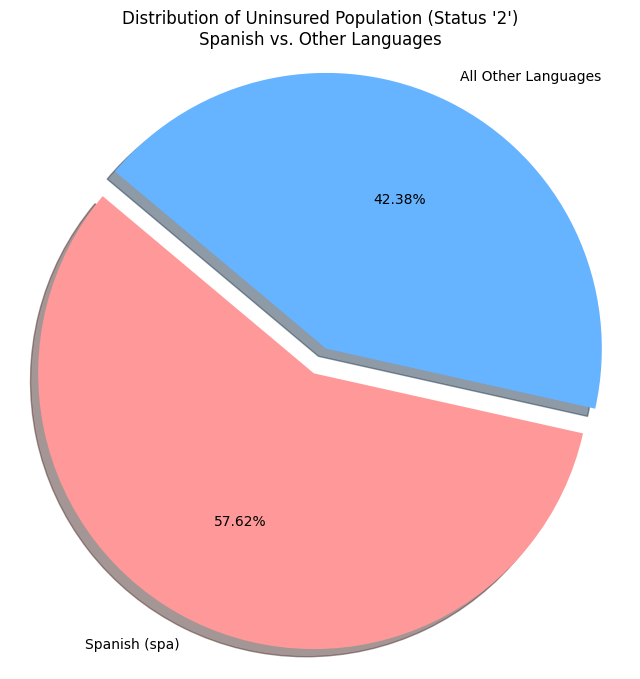

In [45]:
import matplotlib.pyplot as plt

# Calculate counts for the pie chart
spanish_uninsured = lanp_coverage_counts.loc['Spanish (spa)', 2]
total_uninsured = lanp_coverage_counts[2].sum()
others_uninsured = total_uninsured - spanish_uninsured

# Data to plot
labels = ['Spanish (spa)', 'All Other Languages']
sizes = [spanish_uninsured, others_uninsured]
colors = ['#ff9999','#66b3ff']
explode = (0.1, 0)  # explode the Spanish slice

# Create the pie chart
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.2f%%',
        shadow=True, startangle=140)

ax.set_title("Distribution of Uninsured Population (Status '2')\nSpanish vs. Other Languages")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

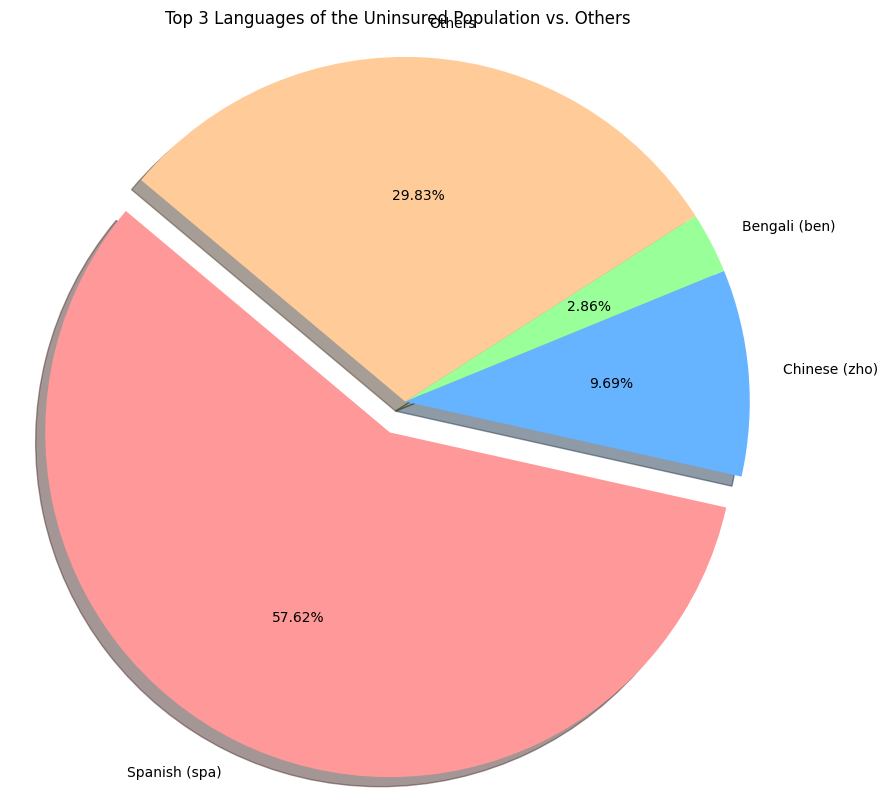

In [46]:
import matplotlib.pyplot as plt

# 1. Get counts of uninsured (status '2') for all languages
uninsured_counts = lanp_coverage_counts[2].sort_values(ascending=False)

# 2. Identify Top 3 and group the rest into 'Others'
top_3_uninsured = uninsured_counts.head(3)
others_count = uninsured_counts.iloc[3:].sum()

# 3. Prepare data for the pie chart
labels = list(top_3_uninsured.index) + ['Others']
sizes = list(top_3_uninsured.values) + [others_count]
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
explode = (0.1, 0, 0, 0)  # Highlight the largest slice

# 4. Create the pie chart
fig, ax = plt.subplots(figsize=(10, 10))
ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.2f%%',
        shadow=True, startangle=140)

ax.set_title("Top 3 Languages of the Uninsured Population vs. Others")
plt.axis('equal')
plt.show()

In [47]:
# 1. Filter for Spanish speakers who are uninsured (Status 2)
# We use df_final as it contains the mapped 'LANP' names
spanish_uninsured_df = df_final[(df_final['LANP'] == 'Spanish (spa)') & (df_final['Overall health insurance coverage'] == 2)]

# 2. Group by PUMA and count occurrences
puma_uninsured_counts = spanish_uninsured_df.groupby('PUMA').size().reset_index(name='Uninsured Spanish Speakers')

# 3. Sort in descending order
puma_uninsured_counts = puma_uninsured_counts.sort_values(by='Uninsured Spanish Speakers', ascending=False)

print("PUMA codes with the most uninsured Spanish speakers:")
display(puma_uninsured_counts)

PUMA codes with the most uninsured Spanish speakers:


,PUMA,Uninsured Spanish Speakers
41,4404,150
40,4403,99
42,4405,70
14,4209,60
12,4207,46
49,4412,45
26,4307,35
46,4409,35
44,4407,35
52,4501,35


### 5. Statistical Analysis
In this section, we examine whether there is a statistically significant association between the language spoken (LANP) and health insurance coverage status (HICOV).

In [48]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Descriptive Statistics: Contingency Table
# We'll use the top 5 languages and group the rest to keep the test robust
top_5_langs = df_final['LANP'].value_counts().nlargest(5).index
df_stat = df_final.copy()
df_stat['Language_Group'] = df_stat['LANP'].apply(lambda x: x if x in top_5_langs else 'Other')

contingency_table = pd.crosstab(df_stat['Language_Group'], df_stat['Overall health insurance coverage'])

print("Contingency Table (Language Group vs Coverage Status):")
display(contingency_table)

# 2. Inferential Statistics: Chi-Squared Test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-squared Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}")
print(f"Degrees of Freedom: {dof}")

if p < 0.05:
    print("\nResult: Statistically Significant (p < 0.05). There is a significant association between language and insurance coverage.")
else:
    print("\nResult: Not Statistically Significant (p >= 0.05). No significant association found.")

Contingency Table (Language Group vs Coverage Status):


Overall health insurance coverage,1,2
Language_Group,,
Bengali (ben),1285,63
Chinese (zho),3429,213
Other,45109,2003
Russian (rus),1426,49
Spanish (spa),10513,1267
Yue Chinese (yue),994,39



Chi-squared Statistic: 792.7614
P-value: 4.2581e-169
Degrees of Freedom: 5

Result: Statistically Significant (p < 0.05). There is a significant association between language and insurance coverage.


### 6. Additional Descriptive Statistics (Mode Analysis)
Since our key variables are categorical, we use the mode to identify the most common occurrences within the uninsured population.

In [49]:
# Identify the mode (most frequent) language among the uninsured
uninsured_only = df_final[df_final['Overall health insurance coverage'] == 2]

mode_language = uninsured_only['LANP'].mode()[0]
mode_count = uninsured_only['LANP'].value_counts().max()

print(f"Descriptive Summary (Uninsured Population):")
print(f"- The Mode (Most Common Language): {mode_language}")
print(f"- Frequency of Mode: {mode_count} individuals")

# Most common PUMA for uninsured speakers
mode_puma = uninsured_only['PUMA'].mode()[0]
print(f"- The Mode (Most Common PUMA): {mode_puma}")

Descriptive Summary (Uninsured Population):
- The Mode (Most Common Language): Spanish (spa)
- Frequency of Mode: 1267 individuals
- The Mode (Most Common PUMA): 4404
